# 质量分级：三档是否合适？

**问题**：当前把 261 家公司分成 L1 强 / L2 中 / L3 弱三档，这个档数是否被数据支持？

**注意一个关键区分**——三档的理由目前是**结构性的**（估值阶梯五级 × 三态"可买/可持有/提醒卖出"恰好铺满），
而不是从数据聚类中得出的。本 notebook 就是来检验后者是否也支持三档，两者不一致时应当知道。

还有一个容易搞错的地方：**当前定档并不是由合成分决定的**，而是由 Q2 护城河分 + Q1 地板 + 旗标的定性规则决定。
所以"合成分能否分三类"和"定档空间能否分三类"是两个不同的问题，下面都会看。

In [1]:
import csv, json, math
import numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Heiti SC', 'Arial Unicode MS', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

PATH = '../data/processed/a_share_quality_scores_v2.csv'
rows = list(csv.DictReader(open(PATH, encoding='utf-8-sig')))
name  = np.array([r['security_name'] for r in rows])
score = np.array([float(r['quality_score']) for r in rows])
q1    = np.array([float(r['q1_business_model_score']) for r in rows])
q2    = np.array([float(r['q2_moat_score']) for r in rows])
q3    = np.array([float(r['q3_capital_allocation_score']) for r in rows])
q4    = np.array([float(r['q4_management_score']) for r in rows])
tier  = np.array([r['quality_tier'] for r in rows])
COLOR = {'L1':'#c0392b', 'L2':'#2980b9', 'L3':'#7f8c8d'}
LABEL = {'L1':'L1 强护城河', 'L2':'L2 中护城河', 'L3':'L3 弱护城河'}
print(f'{len(rows)} 家   参考分 {score.min():.1f}-{score.max():.1f}   均值 {score.mean():.2f}   σ {score.std():.2f}')
for t in ['L1','L2','L3']:
    print(f'  {LABEL[t]}: {(tier==t).sum():>3} 家')

261 家   参考分 48.7-90.2   均值 70.64   σ 5.14
  L1 强护城河:  16 家
  L2 中护城河: 209 家
  L3 弱护城河:  36 家


## 1. 按公司编号的散点图（原始请求）

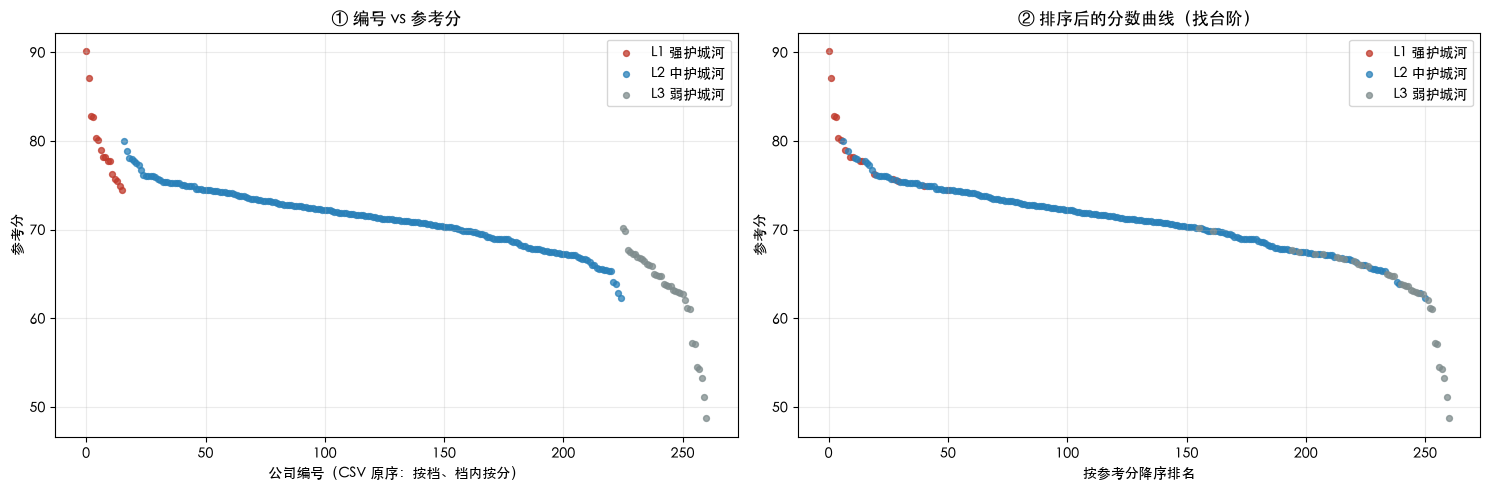

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
for t in ['L1','L2','L3']:
    m = tier == t
    ax.scatter(np.where(m)[0], score[m], s=18, c=COLOR[t], label=LABEL[t], alpha=.75)
ax.set_xlabel('公司编号（CSV 原序：按档、档内按分）'); ax.set_ylabel('参考分')
ax.set_title('① 编号 vs 参考分'); ax.legend(); ax.grid(alpha=.25)

ax = axes[1]
order = np.argsort(-score)
ranks = np.arange(len(score))
for t in ['L1','L2','L3']:
    m = tier[order] == t
    ax.scatter(ranks[m], score[order][m], s=18, c=COLOR[t], label=LABEL[t], alpha=.75)
ax.set_xlabel('按参考分降序排名'); ax.set_ylabel('参考分')
ax.set_title('② 排序后的分数曲线（找台阶）'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

右图是关键：**如果总体真的分成若干类，排序曲线上应出现平台与陡降（台阶状）**。
如果曲线平滑连续，说明总体是连续谱，没有天然分组。

## 2. 分布形态与间隙

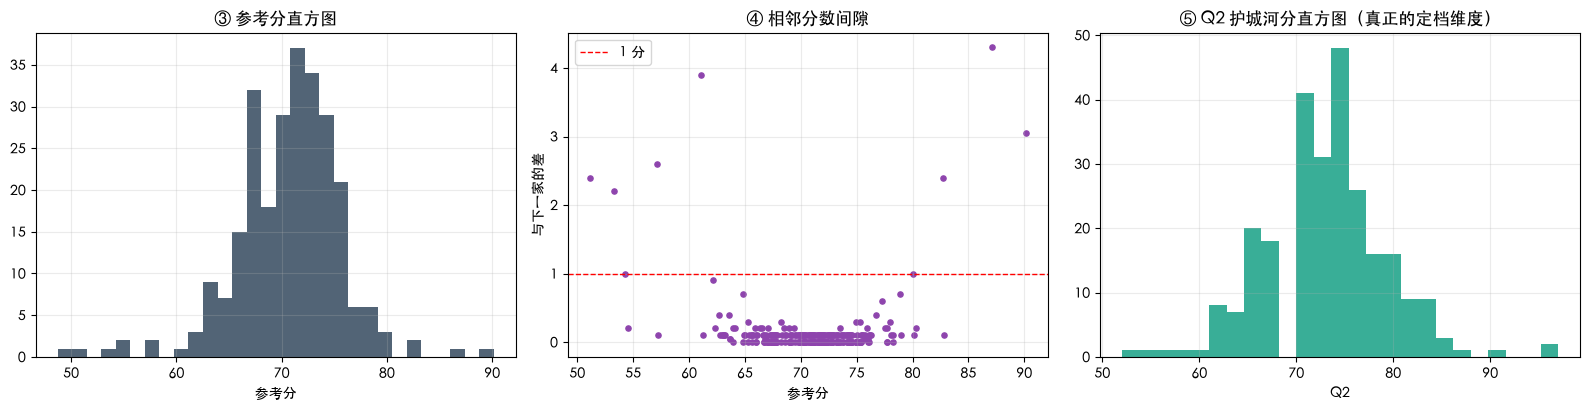

≥1 分的间隙共 9 处；主体（P10-P90=65.0-75.8）内最大间隙 = 0.30


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(score, bins=30, color='#34495e', alpha=.85)
axes[0].set_title('③ 参考分直方图'); axes[0].set_xlabel('参考分'); axes[0].grid(alpha=.25)

s = np.sort(score); gaps = np.diff(s)
axes[1].scatter(s[1:], gaps, s=14, c='#8e44ad')
axes[1].axhline(1.0, ls='--', c='r', lw=1, label='1 分')
axes[1].set_title('④ 相邻分数间隙'); axes[1].set_xlabel('参考分'); axes[1].set_ylabel('与下一家的差')
axes[1].legend(); axes[1].grid(alpha=.25)

axes[2].hist(q2, bins=25, color='#16a085', alpha=.85)
axes[2].set_title('⑤ Q2 护城河分直方图（真正的定档维度）'); axes[2].set_xlabel('Q2'); axes[2].grid(alpha=.25)
plt.tight_layout(); plt.show()

big = [(g, s[i], s[i+1]) for i, g in enumerate(gaps) if g >= 1.0]
print(f'≥1 分的间隙共 {len(big)} 处；主体（P10-P90={np.percentile(score,10):.1f}-{np.percentile(score,90):.1f}）内最大间隙 = ', end='')
core = [(g, s[i]) for i, g in enumerate(gaps) if np.percentile(score,10) <= s[i] <= np.percentile(score,90)]
print(f'{max(g for g,_ in core):.2f}')

## 3. 聚类有效性：k 取几才对？

In [4]:
def kmeans1d(x, k, iters=200):
    """1D k-means，用分位数初始化 + Lloyd 迭代（1D 下足够稳定）"""
    x = np.sort(x)
    c = np.percentile(x, np.linspace(5, 95, k))
    for _ in range(iters):
        lab = np.abs(x[:, None] - c[None, :]).argmin(1)
        nc = np.array([x[lab == j].mean() if (lab == j).any() else c[j] for j in range(k)])
        if np.allclose(nc, c): break
        c = nc
    return lab, c

def silhouette(X, lab):
    """轮廓系数：+1 分离清晰，0 边界模糊，<0 归错类"""
    X = X.reshape(-1, 1) if X.ndim == 1 else X
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    out = []
    for i in range(len(X)):
        same = lab == lab[i]; same[i] = False
        if same.sum() == 0: out.append(0); continue
        a = D[i, same].mean()
        b = min(D[i, lab == j].mean() for j in set(lab) - {lab[i]})
        out.append((b - a) / max(a, b))
    return float(np.mean(out))

print('维度                   k=2    k=3    k=4    k=5    k=6      最佳k')
for lab_txt, data in [('参考分（1D）', score), ('Q2 护城河（1D）', q2),
                      ('Q1xQ2 决策平面（2D）', np.c_[q1, q2])]:
    sils = []
    for k in range(2, 7):
        if data.ndim == 1:
            l, _ = kmeans1d(data, k); sils.append(silhouette(np.sort(data), l))
        else:
            c = data[np.linspace(0, len(data)-1, k).astype(int)].astype(float)
            for _ in range(200):
                l = np.abs(data[:, None, :] - c[None, :, :]).sum(-1).argmin(1)
                nc = np.array([data[l == j].mean(0) if (l == j).any() else c[j] for j in range(k)])
                if np.allclose(nc, c): break
                c = nc
            sils.append(silhouette(data.astype(float), l))
    print(f'{lab_txt:<22}' + '  '.join(f'{v:.3f}' for v in sils) + f'    -> {int(np.argmax(sils))+2}')
print('\n判读：轮廓系数 >0.7 结构强；0.5-0.7 合理；0.25-0.5 弱；<0.25 无实质结构。')
print('若各 k 之间差异很小，说明"最佳k"是噪声，数据不支持任何特定档数。')

维度                   k=2    k=3    k=4    k=5    k=6      最佳k
参考分（1D）               0.554  0.493  0.538  0.549  0.539    -> 2
Q2 护城河（1D）            0.550  0.533  0.567  0.577  0.625    -> 6
Q1xQ2 决策平面（2D）        0.343  0.308  0.325  0.306  0.317    -> 2

判读：轮廓系数 >0.7 结构强；0.5-0.7 合理；0.25-0.5 弱；<0.25 无实质结构。
若各 k 之间差异很小，说明"最佳k"是噪声，数据不支持任何特定档数。


## 4. 真正的定档空间：Q1 × Q2

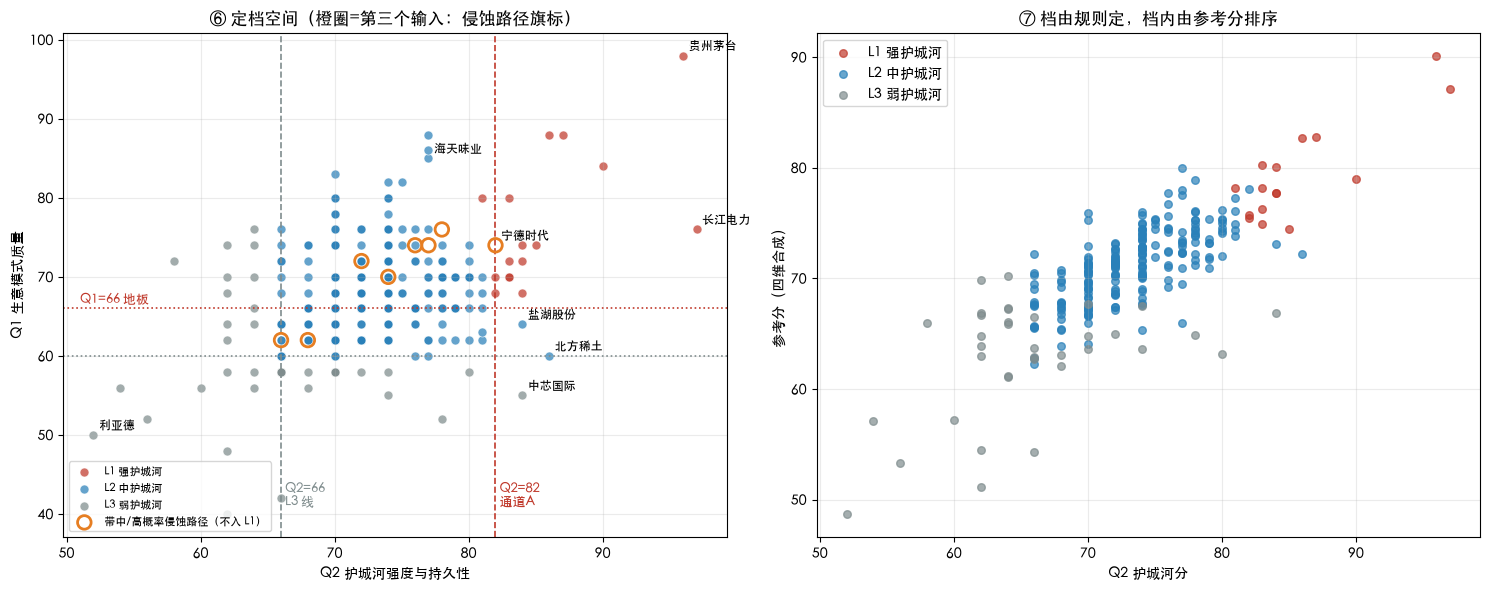

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
import re
flags = np.array([r['flags'] for r in rows])
def ero_block(f):
    m = re.search(r'erosion_path\(([^)]*)\)', f)
    if not m: return False
    s = m.group(1)
    return ('高' in s) or ('中' in s) or ('持续' in s)
blocked = np.array([ero_block(f) for f in flags])

ax = axes[0]
for t in ['L1','L2','L3']:
    m = (tier == t) & ~blocked
    ax.scatter(q2[m], q1[m], s=42, c=COLOR[t], label=LABEL[t], alpha=.72, edgecolors='white', lw=.6)
ax.scatter(q2[blocked], q1[blocked], s=95, facecolors='none', edgecolors='#e67e22', lw=2.0,
           label='带中/高概率侵蚀路径（不入 L1）', zorder=5)
ax.axvline(82, ls='--', c='#c0392b', lw=1.2); ax.axvline(66, ls='--', c='#7f8c8d', lw=1.2)
ax.axhline(66, ls=':', c='#c0392b', lw=1.2); ax.axhline(60, ls=':', c='#7f8c8d', lw=1.2)
ax.text(82.3, 41, 'Q2=82\n通道A', color='#c0392b', fontsize=9)
ax.text(66.3, 41, 'Q2=66\nL3 线', color='#7f8c8d', fontsize=9)
ax.text(51, 66.6, 'Q1=66 地板', color='#c0392b', fontsize=9)
for n in ['贵州茅台','长江电力','中芯国际','北方稀土','宁德时代','海天味业','盐湖股份','利亚德']:
    i = int(np.where(name == n)[0][0])
    ax.annotate(n, (q2[i], q1[i]), fontsize=8.5, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Q2 护城河强度与持久性'); ax.set_ylabel('Q1 生意模式质量')
ax.set_title('⑥ 定档空间（橙圈=第三个输入：侵蚀路径旗标）'); ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=.25)

ax = axes[1]
for t in ['L1','L2','L3']:
    m = tier == t
    ax.scatter(q2[m], score[m], s=30, c=COLOR[t], label=LABEL[t], alpha=.7)
ax.set_xlabel('Q2 护城河分'); ax.set_ylabel('参考分（四维合成）')
ax.set_title('⑦ 档由规则定，档内由参考分排序'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 5. 档内区分度：参考分是否够用

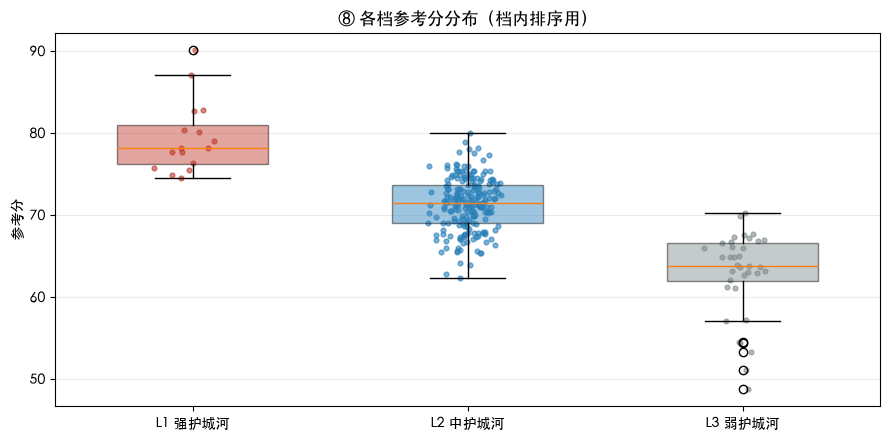

L1 强护城河: n= 16  74.5-90.2  跨度 15.7  σ=4.26
L2 中护城河: n=209  62.3-80.0  跨度 17.7  σ=3.22
L3 弱护城河: n= 36  48.7-70.2  跨度 21.5  σ=5.11

档内差异判例：茅台 90.2 vs 盐湖股份 73.1，同属 L1 但相差 17.1 分


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [score[tier == t] for t in ['L1','L2','L3']]
bp = ax.boxplot(data, tick_labels=[LABEL[t] for t in ['L1','L2','L3']], patch_artist=True, widths=.55)
for p, t in zip(bp['boxes'], ['L1','L2','L3']): p.set_facecolor(COLOR[t]); p.set_alpha(.45)
for i, t in enumerate(['L1','L2','L3']):
    y = score[tier == t]; x = np.random.default_rng(0).normal(i+1, .06, len(y))
    ax.scatter(x, y, s=12, c=COLOR[t], alpha=.6)
ax.set_ylabel('参考分'); ax.set_title('⑧ 各档参考分分布（档内排序用）'); ax.grid(alpha=.25, axis='y')
plt.tight_layout(); plt.show()
for t in ['L1','L2','L3']:
    v = score[tier == t]
    print(f'{LABEL[t]}: n={len(v):>3}  {v.min():.1f}-{v.max():.1f}  跨度 {v.max()-v.min():.1f}  σ={v.std():.2f}')
i_mt = int(np.where(name=='贵州茅台')[0][0]); i_yh = int(np.where(name=='盐湖股份')[0][0])
print(f'\n档内差异判例：茅台 {score[i_mt]:.1f} vs 盐湖股份 {score[i_yh]:.1f}，同属 L1 但相差 {score[i_mt]-score[i_yh]:.1f} 分')

## 6. 结论怎么读

对照下面三条判断三档是否成立：

1. **图②排序曲线**若平滑无台阶 → 总体是连续谱，**任何档数都不会有天然分界**。此时档数不能由数据决定，只能由用途决定。
2. **§3 轮廓系数**若各 k 都 <0.25 → 无实质聚类结构，"最佳 k"没有意义，不应据此选档数。
3. **图⑥定档空间**是档实际被划的地方。看三色是否被 Q2=80 / Q2=66 / Q1=62 三条线干净分开——
   分开说明**规则自洽**（规则划得清楚），但这与"数据本身有三类"仍是两回事。

若 1、2 成立而 3 也成立，正确结论是：
**数据不支持任何特定档数，三档的依据是它与估值阶梯×三态矩阵的结构匹配，以及规则能把它划清楚。**
这时该问的不是"数据像几类"，而是"我需要几种不同的买卖严格度"。